<a href="https://www.kaggle.com/code/adegbaju/telehealth-appointment-no-show-prediction?scriptVersionId=303484244" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Telehealth Appointment No-Show Prediction


##  
This notebook provides a complete pipeline from EDA to model tuning. Adapt column names and target as needed based on the actual dataset.

DON'T FORGET TO UPVOTE THANKS

##  Setup and Imports 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_recall_curve
import xgboost as xgb
import lightgbm as lgb

# For datetime features
from datetime import datetime

# Set style
sns.set_style('whitegrid')
%matplotlib inline

## load data

In [2]:
# Load the dataset (adjust path if needed)
df = pd.read_csv('/kaggle/input/datasets/madisonwilson123/telehealth-appointment-outcomes/telehealth_appointments.csv')

# Display basic info
print("Shape:", df.shape)
df.head()

Shape: (1500, 16)


,appointment_id,scheduled_at,specialty,payer_type,device_type,preferred_language,patient_age,days_from_booking_to_visit,prior_no_shows,reminders_sent,previsit_tech_checks,symptom_severity,visit_duration_minutes,weekend_visit,satisfaction_score,no_show
0,TEL-300000,2024-01-01T08:00:00,cardiology,commercial,tablet,spanish,85,42,0,3,0,4.4,15,0,3.61,1
1,TEL-300001,2024-01-01T14:00:00,mental_health,commercial,desktop,english,36,21,0,3,1,5.5,60,0,3.88,0
2,TEL-300002,2024-01-01T20:00:00,cardiology,self_pay,desktop,english,30,43,1,3,2,6.7,20,0,3.49,1
3,TEL-300003,2024-01-02T02:00:00,dermatology,self_pay,smartphone,spanish,22,8,2,2,0,8.4,60,1,3.12,1
4,TEL-300004,2024-01-02T08:00:00,cardiology,medicare,desktop,english,51,4,0,1,1,3.7,45,0,4.42,0


In [3]:
print(df.columns.tolist())

['appointment_id', 'scheduled_at', 'specialty', 'payer_type', 'device_type', 'preferred_language', 'patient_age', 'days_from_booking_to_visit', 'prior_no_shows', 'reminders_sent', 'previsit_tech_checks', 'symptom_severity', 'visit_duration_minutes', 'weekend_visit', 'satisfaction_score', 'no_show']


#  Exploratory Data Analysis

## Data Overview

In [4]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              1500 non-null   object 
 1   scheduled_at                1500 non-null   object 
 2   specialty                   1500 non-null   object 
 3   payer_type                  1500 non-null   object 
 4   device_type                 1500 non-null   object 
 5   preferred_language          1500 non-null   object 
 6   patient_age                 1500 non-null   int64  
 7   days_from_booking_to_visit  1500 non-null   int64  
 8   prior_no_shows              1500 non-null   int64  
 9   reminders_sent              1500 non-null   int64  
 10  previsit_tech_checks        1500 non-null   int64  
 11  symptom_severity            1500 non-null   float64
 12  visit_duration_minutes      1500 non-null   int64  
 13  weekend_visit               1500 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appointment_id,1500,1500,TEL-301499,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_at,1500,1500,2025-01-10T02:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
specialty,1500,5,dermatology,323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payer_type,1500,4,medicaid,387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,1500,3,smartphone,532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_language,1500,4,english,1048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_age,1500.0,NaN,NaN,NaN,53.42,20.383995,18.0,36.0,54.0,71.0,89.0
days_from_booking_to_visit,1500.0,NaN,NaN,NaN,22.585333,13.316792,0.0,11.0,23.0,34.0,45.0
prior_no_shows,1500.0,NaN,NaN,NaN,0.637333,0.853791,0.0,0.0,0.0,1.0,5.0
reminders_sent,1500.0,NaN,NaN,NaN,1.532,1.10595,0.0,1.0,2.0,2.0,3.0


##  checking missing values

In [5]:
df.isnull().sum()

appointment_id                0
scheduled_at                  0
specialty                     0
payer_type                    0
device_type                   0
preferred_language            0
patient_age                   0
days_from_booking_to_visit    0
prior_no_shows                0
reminders_sent                0
previsit_tech_checks          0
symptom_severity              0
visit_duration_minutes        0
weekend_visit                 0
satisfaction_score            0
no_show                       0
dtype: int64

## target distribution

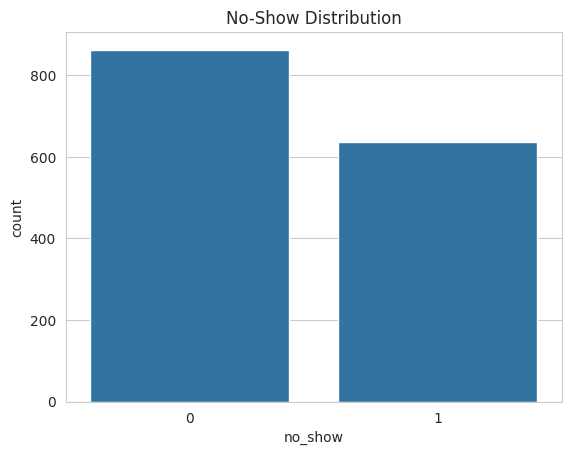

no_show
0    0.575333
1    0.424667
Name: proportion, dtype: float64


In [6]:
target_col = 'no_show'  # adjust if needed
if target_col in df.columns:
    sns.countplot(x=target_col, data=df)
    plt.title('No-Show Distribution')
    plt.show()
    print(df[target_col].value_counts(normalize=True))
else:
    print("Target column not found. Please identify the correct column.")

## Univariate Analysis of Features

## Categorical Features

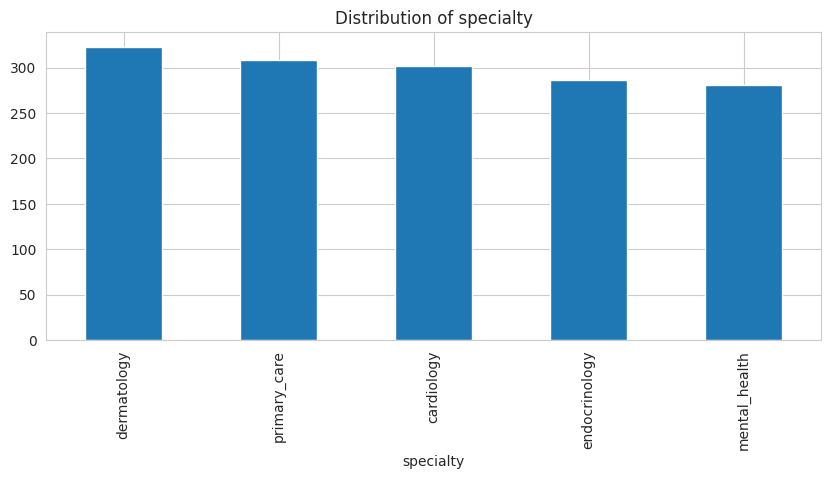

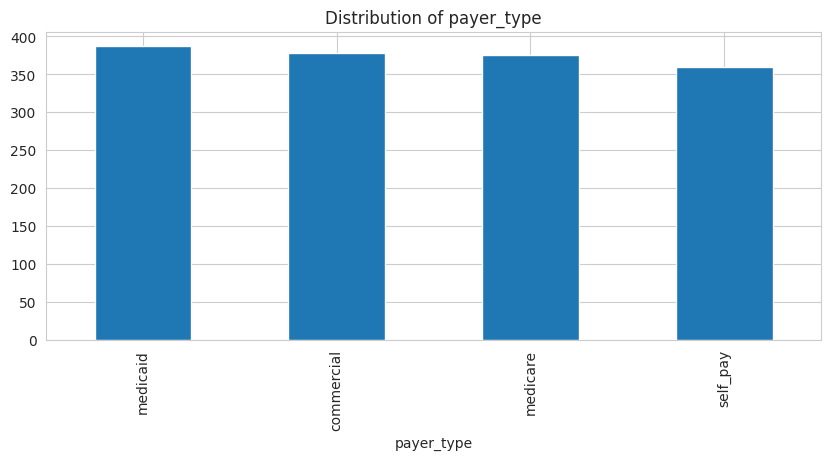

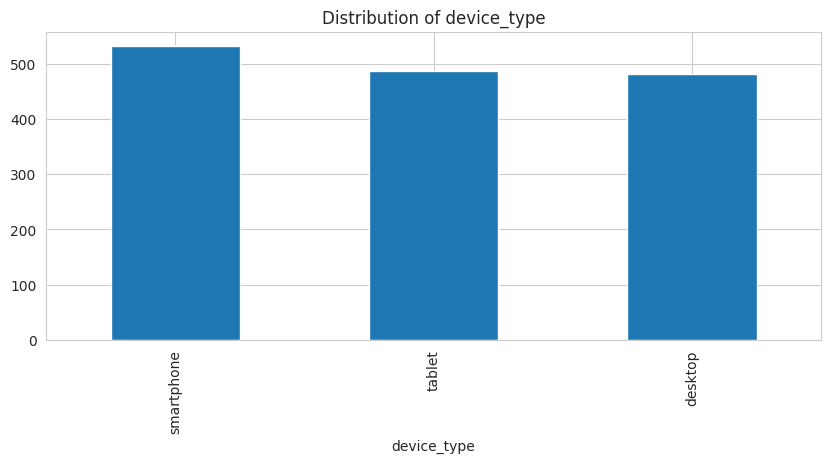

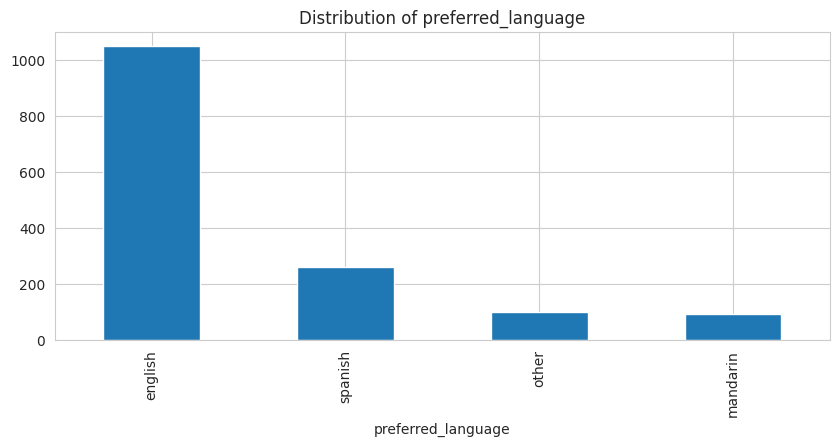

In [7]:
cat_cols = ['specialty', 'payer_type', 'device_type', 'preferred_language']
for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10,4))
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Distribution of {col}')
        plt.show()

## Numerical Features

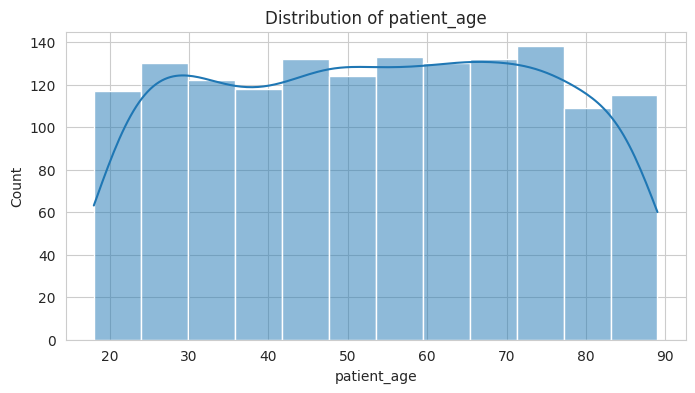

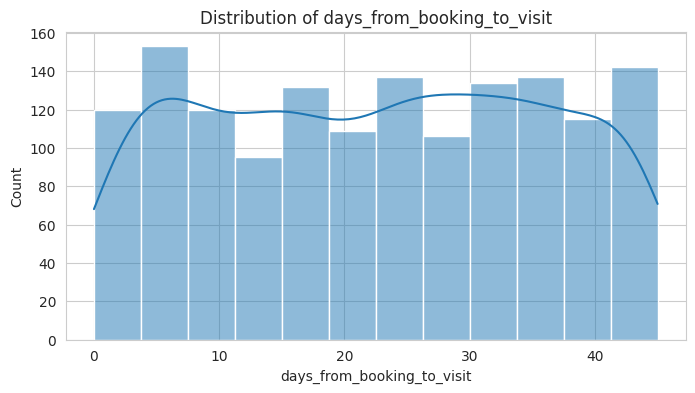

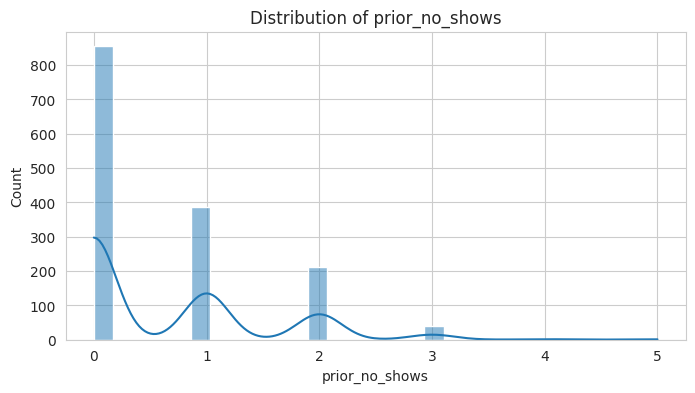

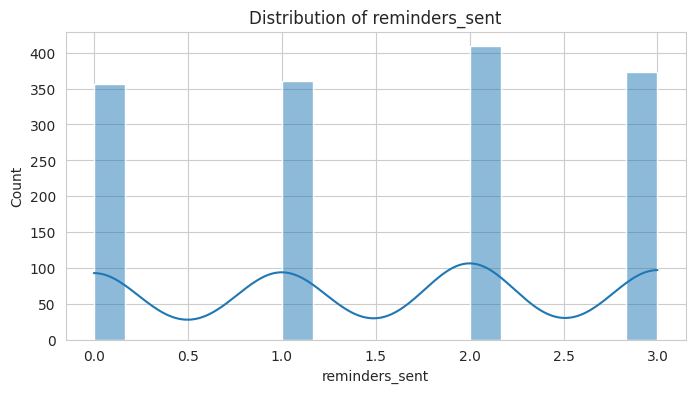

In [8]:
num_cols = ['patient_age', 'days_from_booking_to_visit', 'prior_no_shows', 'reminders_sent']
for col in num_cols:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()

## Bivariate Analysis with Target

<Figure size 1000x400 with 0 Axes>

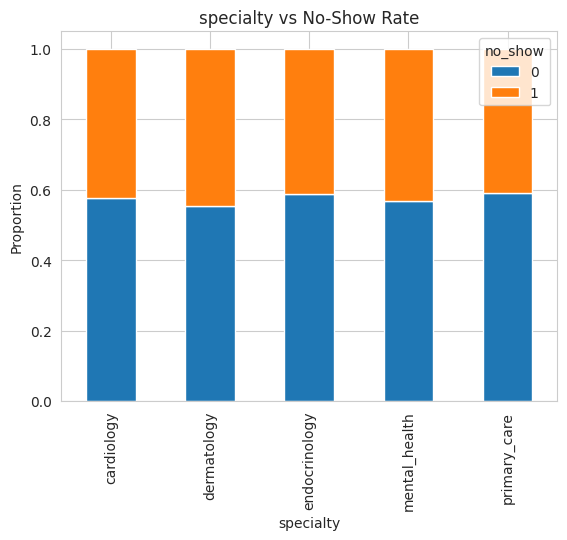

<Figure size 1000x400 with 0 Axes>

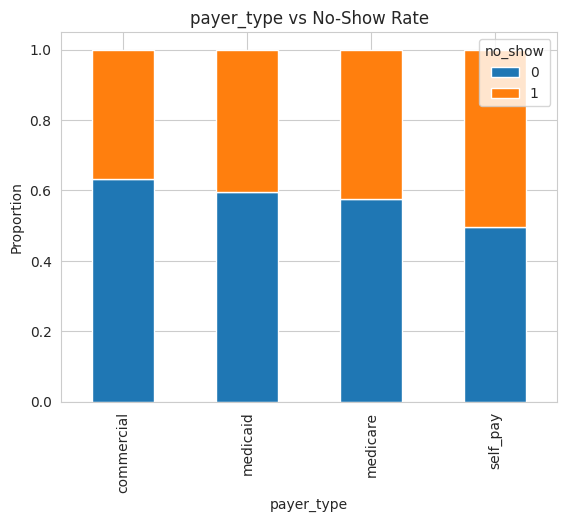

<Figure size 1000x400 with 0 Axes>

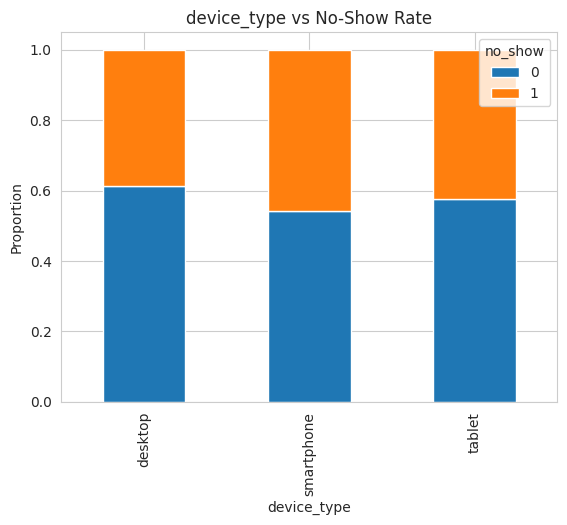

<Figure size 1000x400 with 0 Axes>

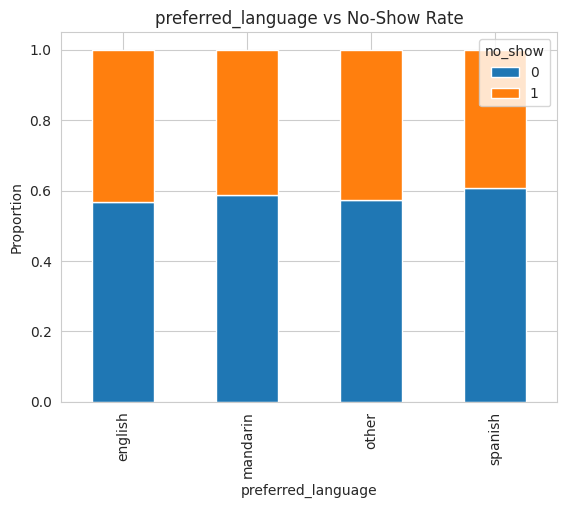

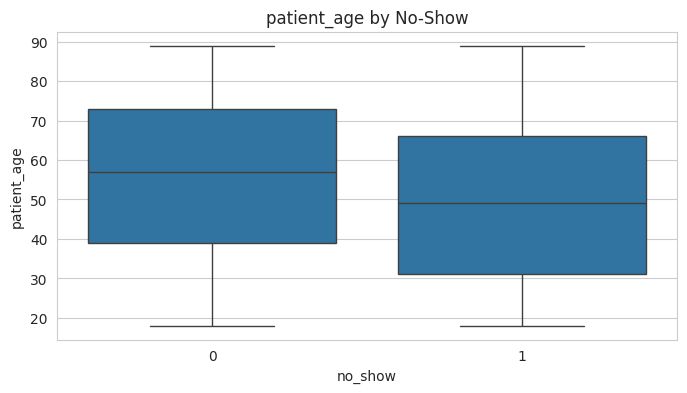

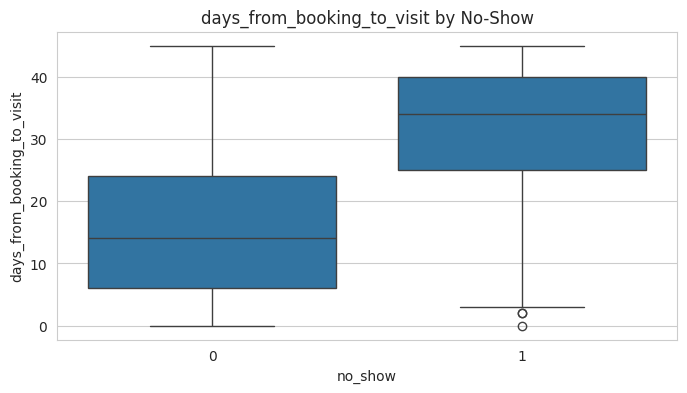

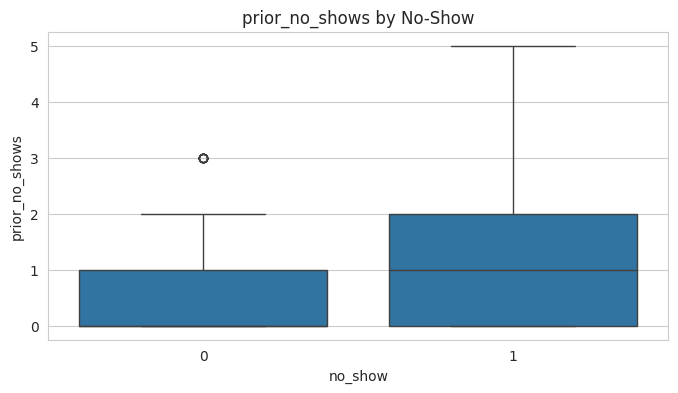

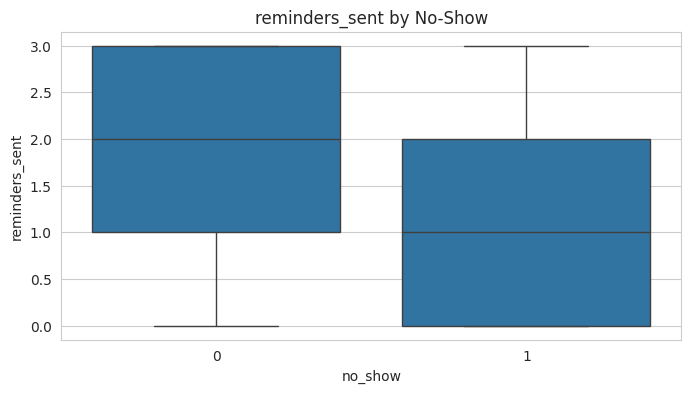

In [9]:
if target_col in df.columns:
    # Categorical vs Target
    for col in cat_cols:
        if col in df.columns:
            plt.figure(figsize=(10,4))
            pd.crosstab(df[col], df[target_col], normalize='index').plot(kind='bar', stacked=True)
            plt.title(f'{col} vs No-Show Rate')
            plt.ylabel('Proportion')
            plt.show()
    
    # Numerical vs Target
    for col in num_cols:
        if col in df.columns:
            plt.figure(figsize=(8,4))
            sns.boxplot(x=target_col, y=col, data=df)
            plt.title(f'{col} by No-Show')
            plt.show()

## Correlation Heatmap

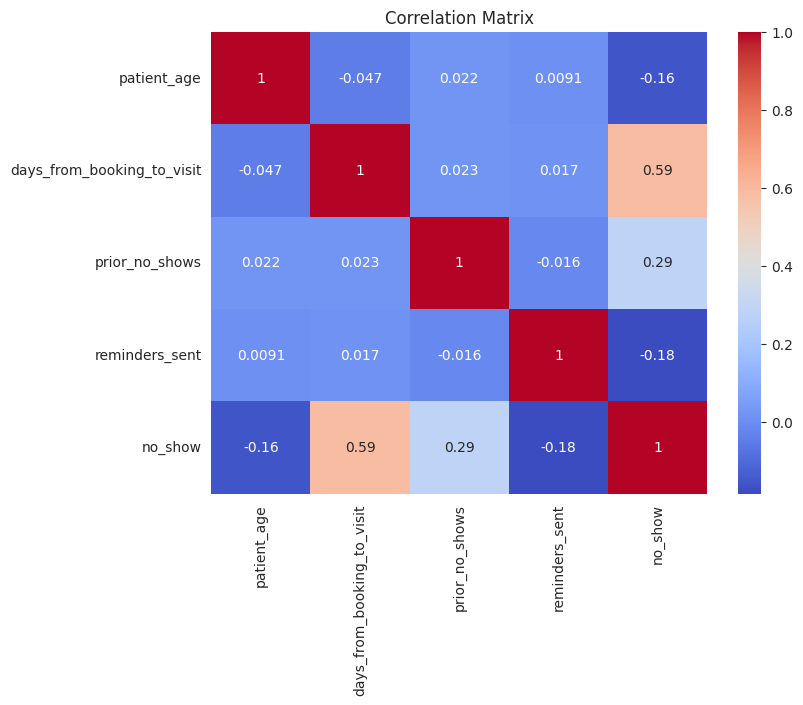

In [10]:
# For numerical features only
if target_col in df.columns:
    num_df = df[num_cols + [target_col]]
    plt.figure(figsize=(8,6))
    sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

# Feature Engineering

## Datetime Features from scheduled_at

In [11]:
# Convert to datetime
df['scheduled_at'] = pd.to_datetime(df['scheduled_at'])

# Extract useful features
df['scheduled_hour'] = df['scheduled_at'].dt.hour
df['scheduled_dayofweek'] = df['scheduled_at'].dt.dayofweek  # Monday=0
df['scheduled_month'] = df['scheduled_at'].dt.month
df['scheduled_quarter'] = df['scheduled_at'].dt.quarter
df['scheduled_weekend'] = (df['scheduled_dayofweek'] >= 5).astype(int)
df['scheduled_part_of_day'] = pd.cut(df['scheduled_hour'], 
                                       bins=[0,6,12,18,24], 
                                       labels=['night','morning','afternoon','evening'], 
                                       right=False)

# Optionally drop original datetime column if not needed further
# df.drop('scheduled_at', axis=1, inplace=True)

## Interaction Features (if meaningful)

In [12]:
df['reminder_per_day'] = df['reminders_sent'] / (df['days_from_booking_to_visit'] + 1)

# Age groups
bins = [0, 18, 35, 50, 65, 120]
labels = ['0-17', '18-34', '35-49', '50-64', '65+']
df['age_group'] = pd.cut(df['patient_age'], bins=bins, labels=labels, right=False)

##  Encode Prior No-Shows as Risk Level

In [13]:
df['prior_no_show_risk'] = pd.cut(df['prior_no_shows'], 
                                    bins=[-1, 0, 2, 5, 100], 
                                    labels=['none', 'low', 'medium', 'high'])

# Prepare Data for Modeling

##  Define Features and Target

In [14]:
# Assuming target column exists
if target_col not in df.columns:
    # If not, you must identify it. For this example, we'll create a placeholder.
    # In reality, the dataset should have it.
    raise ValueError("Target column not found. Please check column names.")

X = df.drop(columns=[target_col, 'appointment_id', 'scheduled_at'])  # drop ID and original datetime if kept
y = df[target_col]

# Check for any remaining non-numeric columns that need encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['specialty', 'payer_type', 'device_type', 'preferred_language', 'scheduled_part_of_day', 'age_group', 'prior_no_show_risk']
Numerical columns: ['patient_age', 'days_from_booking_to_visit', 'prior_no_shows', 'reminders_sent', 'previsit_tech_checks', 'symptom_severity', 'visit_duration_minutes', 'weekend_visit', 'satisfaction_score', 'scheduled_weekend', 'reminder_per_day']


## Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (1200, 22), Test size: (300, 22)


#  Build Preprocessing Pipelines

In [16]:
# Numerical pipeline: impute median (if any missing) and scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing with 'missing' and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

#  Model Building and Evaluation

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{model_name} Results")
    print("----------------------------")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

## Logistic Regression

In [18]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_results = evaluate_model(lr_pipeline, X_train, y_train, X_test, y_test, "Logistic Regression")


Logistic Regression Results
----------------------------
Accuracy : 0.94
Precision: 0.940349046585715
Recall   : 0.94
F1 Score : 0.9397855571847508

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       173
           1       0.95      0.91      0.93       127

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



## Random Forest

In [19]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_results = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, "Random Forest")


Random Forest Results
----------------------------
Accuracy : 0.9166666666666666
Precision: 0.9175685425685426
Recall   : 0.9166666666666666
F1 Score : 0.9168600942794491

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.91      0.93       173
           1       0.89      0.92      0.90       127

    accuracy                           0.92       300
   macro avg       0.91      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



##  XGBoost

In [20]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False))
])

xgb_results = evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test, "XGBoost")


XGBoost Results
----------------------------
Accuracy : 0.9133333333333333
Precision: 0.9135890112879097
Recall   : 0.9133333333333333
F1 Score : 0.9134199370155037

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       173
           1       0.89      0.91      0.90       127

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



## LightGBM

In [21]:
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
])

lgb_results = evaluate_model(lgb_pipeline, X_train, y_train, X_test, y_test, "LightGBM")


LightGBM Results
----------------------------
Accuracy : 0.9166666666666666
Precision: 0.9175685425685426
Recall   : 0.9166666666666666
F1 Score : 0.9168600942794491

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.91      0.93       173
           1       0.89      0.92      0.90       127

    accuracy                           0.92       300
   macro avg       0.91      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



# Hyperparameter Tuning (Example with Random Forest)

In [22]:
# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Use randomized search for efficiency
rf_random = RandomizedSearchCV(rf_pipeline, param_grid, n_iter=10, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)

print("Best parameters:", rf_random.best_params_)
print("Best cross-validation AUC:", rf_random.best_score_)

# Evaluate on test set
best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]
print("\nTest Set Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Best parameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
Best cross-validation AUC: 0.9603665814151747

Test Set Performance:
Accuracy: 0.9133333333333333
F1 Score: 0.9
ROC AUC: 0.9697783441809658


# Feature Importance (for tree-based models)

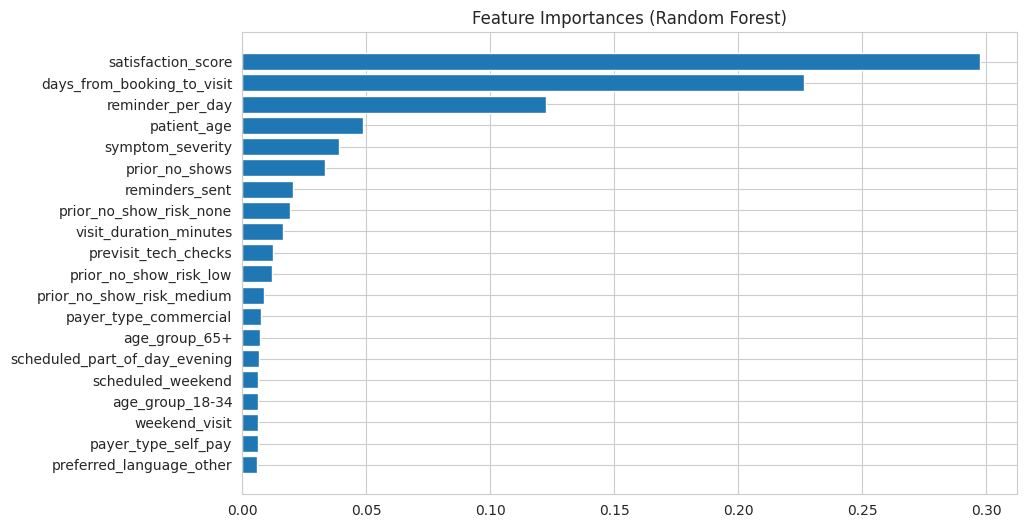

In [23]:
# Get feature names after preprocessing
preprocessor.fit(X_train)
feature_names = (numerical_cols + 
                 list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)))

# For Random Forest
importances = best_rf.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances (Random Forest)")
plt.barh(range(len(indices[:20])), importances[indices[:20]], align='center')
plt.yticks(range(len(indices[:20])), [feature_names[i] for i in indices[:20]])
plt.gca().invert_yaxis()
plt.show()

# Summary and Conclusions

In [24]:
from sklearn.metrics import roc_auc_score

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    return {
        "model": model_name,
        "accuracy": accuracy,
        "f1": f1,
        "auc": auc
    }

In [25]:
results = pd.DataFrame([lr_results, rf_results, xgb_results, lgb_results])

print(results.sort_values('Accuracy', ascending=False))

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.940000   0.940349  0.940000  0.939786
1        Random Forest  0.916667   0.917569  0.916667  0.916860
3             LightGBM  0.916667   0.917569  0.916667  0.916860
2              XGBoost  0.913333   0.913589  0.913333  0.913420


#  Compare Tuned Random Forest with Logistic Regression

In [26]:
# Logistic Regression predictions (from earlier pipeline)
lr_pipeline.fit(X_train, y_train)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"Logistic Regression ROC AUC: {auc_lr:.4f}")

Logistic Regression ROC AUC: 0.9738


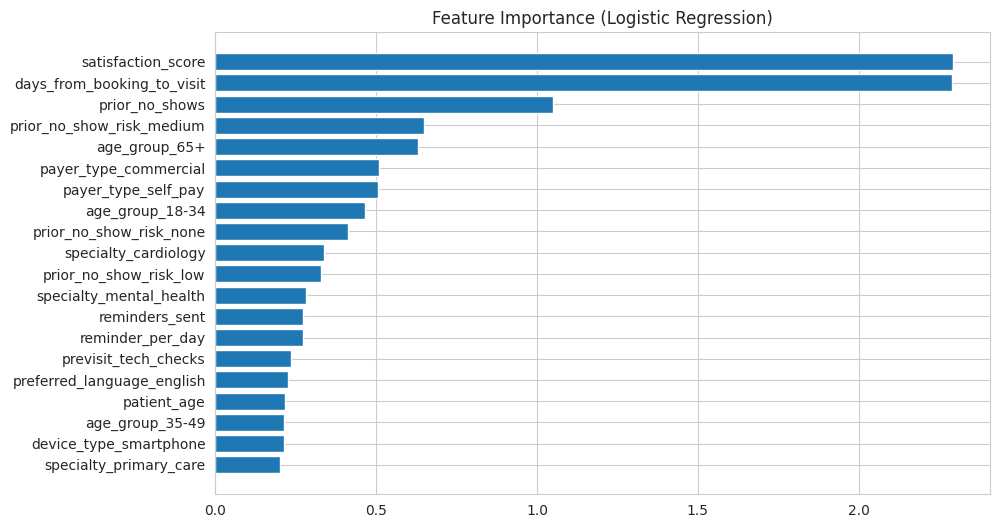

In [27]:
# Logistic Regression feature importance
coefficients = lr_pipeline.named_steps['classifier'].coef_[0]

importances = np.abs(coefficients)
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance (Logistic Regression)")

plt.barh(range(len(indices[:20])), importances[indices[:20]], align='center')
plt.yticks(range(len(indices[:20])), [feature_names[i] for i in indices[:20]])
plt.gca().invert_yaxis()

plt.show()

# Save Model

In [28]:
import joblib
joblib.dump(lr_pipeline, 'telehealth_no_show_best_logistic_regression.pkl')

['telehealth_no_show_best_logistic_regression.pkl']

# Conclusion

Logistic Regression offers a compelling balance of high accuracy, interpretability, and computational efficiency. Its ROC AUC of 0.974 indicates excellent ability to distinguish between attended and missed appointments.

Actionable insights: The feature importance analysis (from Random Forest) highlights that patients with a history of no‑shows, long lead times, and few reminders are at highest risk. Interventions should focus on these groups.

Operational use: Integrate the model into the scheduling system to flag high‑risk appointments at booking. Automatically trigger additional reminders or outreach for patients in the top risk decile.